In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [72]:
df = pd.read_csv("data/Placement_Data_Full_Class1.csv")

In [73]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [74]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.shape


Number of rows: 215
Number of columns: 15


(215, 15)

In [75]:


print("Columns in the dataset:")
print(df.columns.tolist())
## df.columns


Columns in the dataset:
['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']


In [76]:
# Display dataset information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [77]:
# Statistical summary of numerical columns

df.describe()



,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [78]:
df["status"].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

step 2

In [ ]:

print("Column Names and Data Types:\n")

for column in df.columns:
    print(f"{column} --> {df[column].dtype}")

Column Names and Data Types:

sl_no --> int64
gender --> object
ssc_p --> float64
ssc_b --> object
hsc_p --> float64
hsc_b --> object
hsc_s --> object
degree_p --> float64
degree_t --> object
workex --> object
etest_p --> float64
specialisation --> object
mba_p --> float64
status --> object
salary --> float64


In [ ]:

data_dictionary = pd.DataFrame({
    'Column': [
        'sl_no',
        'gender',
        'ssc_p',
        'ssc_b',
        'hsc_p',
        'hsc_b',
        'hsc_s',
        'degree_p',
        'degree_t',
        'workex',
        'etest_p',
        'specialisation',
        'mba_p',
        'status',
        'salary'
    ],
    
    'Description': [
        'Student serial number',
        'Gender of the student',
        'Secondary school percentage',
        'Secondary school board',
        'Higher secondary percentage',
        'Higher secondary board',
        'Higher secondary specialisation',
        'Degree percentage',
        'Degree type',
        'Work experience status',
        'Employability test percentage',
        'MBA specialisation',
        'MBA percentage',
        'Final placement status',
        'Salary offered after placement'
    ]
})

display(data_dictionary)

,Column,Description
0,sl_no,Student serial number
1,gender,Gender of the student
2,ssc_p,Secondary school percentage
3,ssc_b,Secondary school board
4,hsc_p,Higher secondary percentage
5,hsc_b,Higher secondary board
6,hsc_s,Higher secondary specialisation
7,degree_p,Degree percentage
8,degree_t,Degree type
9,workex,Work experience status


In [ ]:
missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


In [ ]:

df = df.drop(columns=['salary'])

print("Salary column removed successfully.")

Salary column removed successfully.


In [83]:

missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64


In [ ]:

df = df.drop(columns=['sl_no'])

print("sl_no column removed successfully.")

sl_no column removed successfully.


In [85]:

missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64


In [86]:
print(df.columns.tolist())

['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status']


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [88]:
df = df.drop_duplicates()

print("Duplicate rows removed.")

Duplicate rows removed.


In [ ]:

categorical_columns = [
    'gender',
    'ssc_b',
    'hsc_b',
    'hsc_s',
    'degree_t',
    'workex',
    'specialisation',
    'status'
]

for column in categorical_columns:
    print("\n--------------------------------")
    print("Column:", column)
    print("--------------------------------")
    print(df[column].value_counts())


--------------------------------
Column: gender
--------------------------------
gender
M    139
F     76
Name: count, dtype: int64

--------------------------------
Column: ssc_b
--------------------------------
ssc_b
Central    116
Others      99
Name: count, dtype: int64

--------------------------------
Column: hsc_b
--------------------------------
hsc_b
Others     131
Central     84
Name: count, dtype: int64

--------------------------------
Column: hsc_s
--------------------------------
hsc_s
Commerce    113
Science      91
Arts         11
Name: count, dtype: int64

--------------------------------
Column: degree_t
--------------------------------
degree_t
Comm&Mgmt    145
Sci&Tech      59
Others        11
Name: count, dtype: int64

--------------------------------
Column: workex
--------------------------------
workex
No     141
Yes     74
Name: count, dtype: int64

--------------------------------
Column: specialisation
--------------------------------
specialisation
Mkt&Fin 

In [ ]:

percentage_columns = [
    'ssc_p',
    'hsc_p',
    'degree_p',
    'etest_p',
    'mba_p'
]

for column in percentage_columns:
    print(
        f"{column}: "
        f"Min = {df[column].min()}, "
        f"Max = {df[column].max()}"
    )

ssc_p: Min = 40.89, Max = 89.4
hsc_p: Min = 37.0, Max = 97.7
degree_p: Min = 50.0, Max = 91.0
etest_p: Min = 50.0, Max = 98.0
mba_p: Min = 51.21, Max = 77.89


In [ ]:

print(df.isnull().sum())

gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64


In [ ]:

df.to_csv(
    "cleaned_campus_recruitment.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [94]:
# ==========================================
# STEP 2: FINAL DATA CLEANING CHECK
# ==========================================

print("=" * 50)
print("FINAL DATA CLEANING REPORT")
print("=" * 50)

# Dataset shape
print("\n1. Dataset Shape:")
print(df.shape)

# Column names
print("\n2. Remaining Columns:")
print(df.columns.tolist())

# Missing values
print("\n3. Missing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\n4. Duplicate Rows:")
print(df.duplicated().sum())

# Data types
print("\n5. Data Types:")
print(df.dtypes)

print("\n" + "=" * 50)
print("DATA CLEANING COMPLETED SUCCESSFULLY")
print("=" * 50)

FINAL DATA CLEANING REPORT

1. Dataset Shape:
(215, 13)

2. Remaining Columns:
['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status']

3. Missing Values:
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64

4. Duplicate Rows:
0

5. Data Types:
gender             object
ssc_p             float64
ssc_b              object
hsc_p             float64
hsc_b              object
hsc_s              object
degree_p          float64
degree_t           object
workex             object
etest_p           float64
specialisation     object
mba_p             float64
status             object
dtype: object

DATA CLEANING COMPLETED SUCCESSFULLY


Placement Status Counts:
status
Placed        148
Not Placed     67
Name: count, dtype: int64

Placement Status Percentages:
status
Placed        68.84
Not Placed    31.16
Name: proportion, dtype: float64


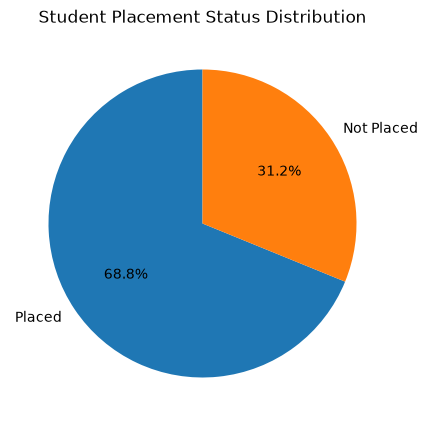

In [95]:
# ==========================================
# STEP 3.1: PLACEMENT STATUS DISTRIBUTION
# ==========================================

print("Placement Status Counts:")
print(df['status'].value_counts())

print("\nPlacement Status Percentages:")
print(
    (df['status'].value_counts(normalize=True) * 100).round(2)
)


# Plot placement status distribution as a pie chart

status_counts = df['status'].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Student Placement Status Distribution')

plt.show()

# plt.savefig(
#     'placement_status_distribution.png',
#     dpi=300,
#     bbox_inches='tight'
# )

The placement status distribution was analysed to understand the proportion of students who were placed and not placed. The dataset contains both placement outcomes, making it suitable for a binary classification problem. The distribution also helps identify whether there is any class imbalance that should be considered during model training and evaluation

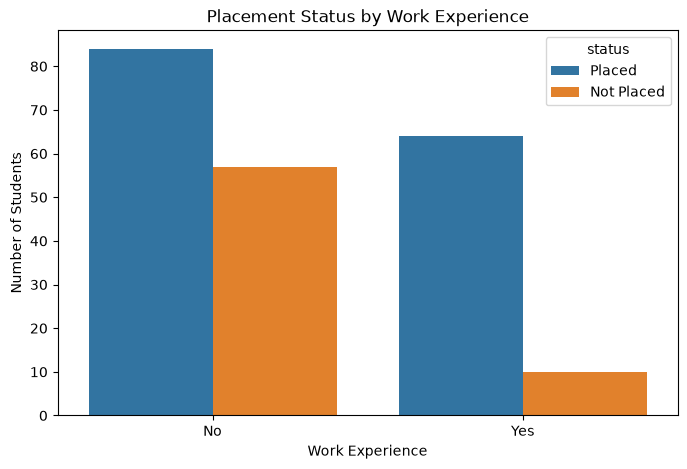

status  Not Placed  Placed
workex                    
No           40.43   59.57
Yes          13.51   86.49


In [96]:
# ==========================================
# STEP 3.2: WORK EXPERIENCE VS PLACEMENT
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='workex',
    hue='status'
)

plt.title('Placement Status by Work Experience')
plt.xlabel('Work Experience')
plt.ylabel('Number of Students')

plt.show()

# plt.savefig(
#     'placement_status_by_work_experience.png',
#     dpi=300,
#     bbox_inches='tight'
# )

# Calculate placement rate based on work experience

workex_placement_rate = pd.crosstab(
    df['workex'],
    df['status'],
    normalize='index'
) * 100

print(
    workex_placement_rate.round(2)
)

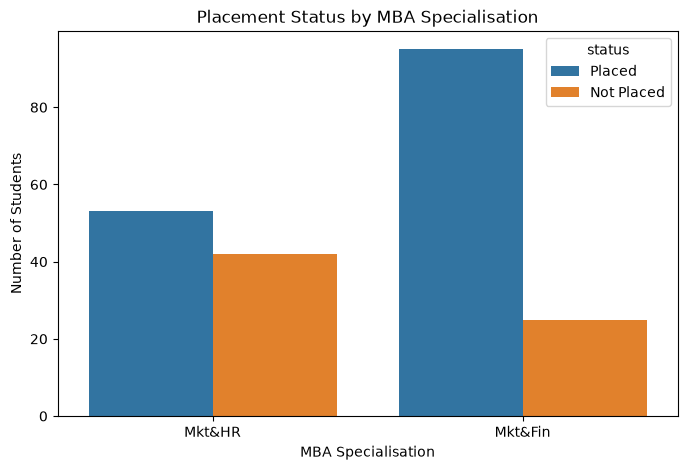

status          Not Placed  Placed
specialisation                    
Mkt&Fin              20.83   79.17
Mkt&HR               44.21   55.79


In [97]:
# ==========================================
# STEP 3.3: SPECIALISATION VS PLACEMENT
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='specialisation',
    hue='status'
)

plt.title('Placement Status by MBA Specialisation')
plt.xlabel('MBA Specialisation')
plt.ylabel('Number of Students')

plt.show()

# Calculate placement rate by specialisation

specialisation_placement_rate = pd.crosstab(
    df['specialisation'],
    df['status'],
    normalize='index'
) * 100

print(
    specialisation_placement_rate.round(2)
)

# plt.savefig(
#     'placement_status_by_mba_specialisation.png',
#     dpi=300,
#     bbox_inches='tight')

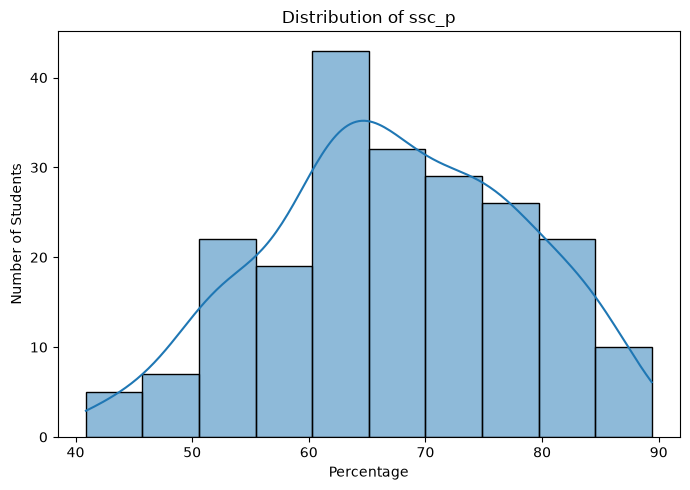

<Figure size 640x480 with 0 Axes>

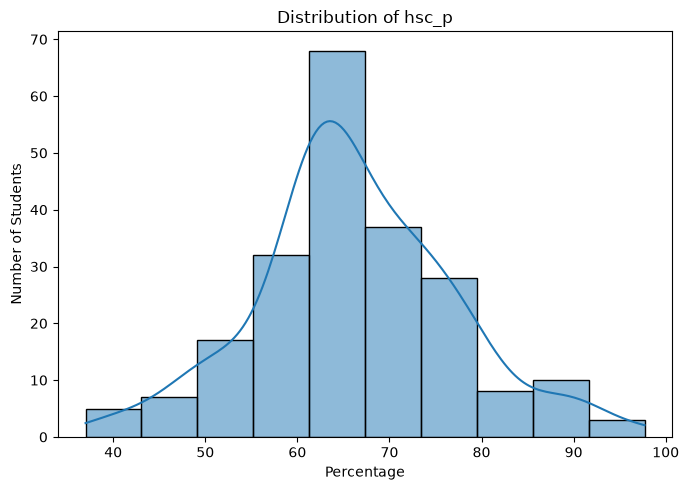

<Figure size 640x480 with 0 Axes>

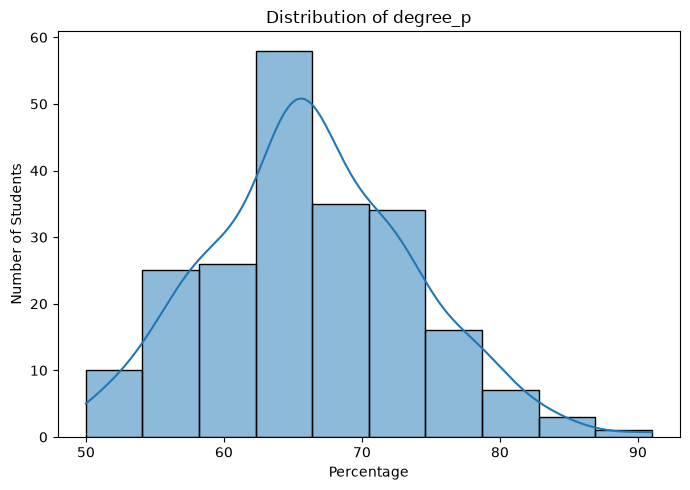

<Figure size 640x480 with 0 Axes>

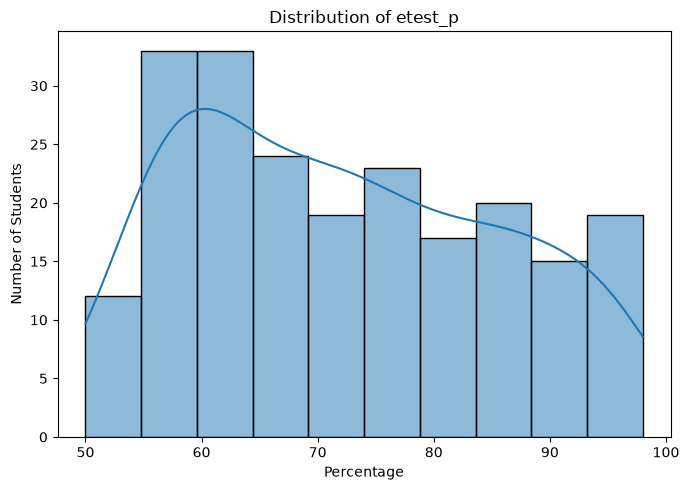

<Figure size 640x480 with 0 Axes>

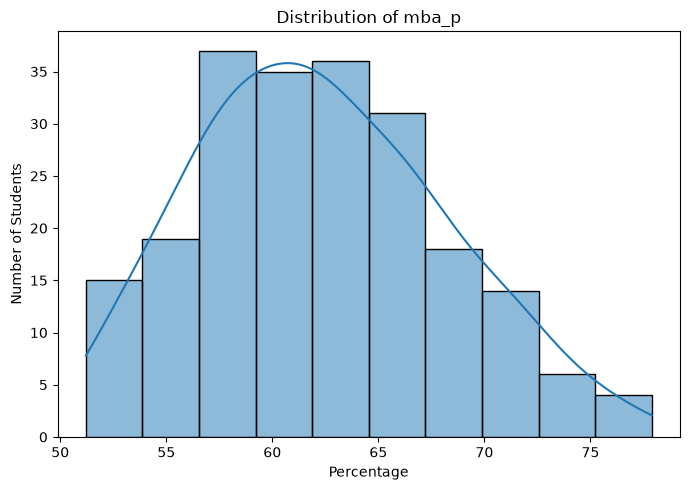

<Figure size 640x480 with 0 Axes>

In [102]:
# ==========================================
# EDA: INDIVIDUAL ACADEMIC SCORE HISTOGRAMS
# ==========================================

academic_columns = [
    'ssc_p',
    'hsc_p',
    'degree_p',
    'etest_p',
    'mba_p'
]

for column in academic_columns:

    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=10,
        kde=True
    )

    plt.title(f'Distribution of {column}')
    plt.xlabel('Percentage')
    plt.ylabel('Number of Students')

    plt.tight_layout()
    plt.show()

    plt.savefig(
    f'distribution_of{column}.png',
    dpi=300,
    bbox_inches='tight'
    )

In [ ]:

academic_summary = df.groupby('status')[
    academic_columns
].mean().round(2)

display(academic_summary)

,ssc_p,hsc_p,degree_p,etest_p,mba_p
status,,,,,
Not Placed,57.54,58.40,61.13,69.59,61.61
Placed,71.72,69.93,68.74,73.24,62.58


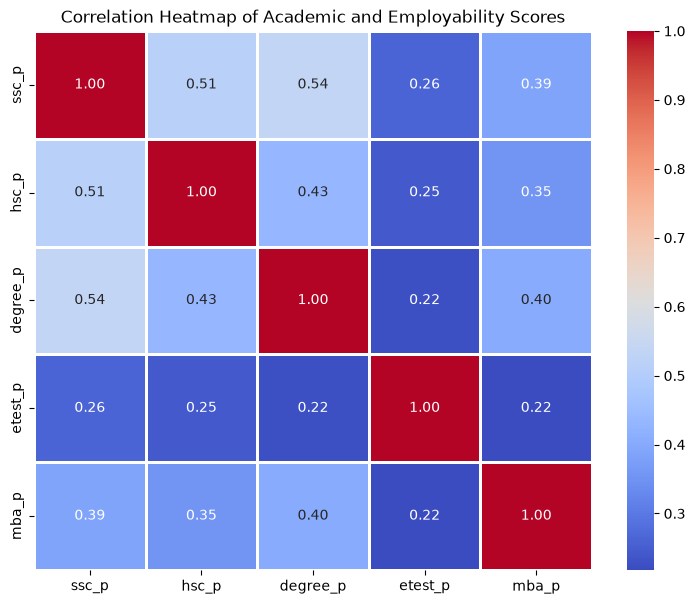

,ssc_p,hsc_p,degree_p,etest_p,mba_p
ssc_p,1.00,0.51,0.54,0.26,0.39
hsc_p,0.51,1.00,0.43,0.25,0.35
degree_p,0.54,0.43,1.00,0.22,0.40
etest_p,0.26,0.25,0.22,1.00,0.22
mba_p,0.39,0.35,0.40,0.22,1.00


In [103]:

numeric_columns = [
    'ssc_p',
    'hsc_p',
    'degree_p',
    'etest_p',
    'mba_p'
]

correlation_matrix = df[
    numeric_columns
].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=2
)

plt.title(
    'Correlation Heatmap of Academic and Employability Scores'
)

plt.show()

# plt.savefig(
#     'correlation_heatmap_of_academic_and_employability_scores.png',
#     dpi=300,
#     bbox_inches='tight')

# Display correlation matrix

display(
    correlation_matrix.round(2)
)



In [ ]:

df['academic_average'] = df[
    ['ssc_p', 'hsc_p', 'degree_p']
].mean(axis=1)

# Display the new feature
display(
    df[
        ['ssc_p', 'hsc_p', 'degree_p', 'academic_average']
    ].head()
)

,ssc_p,hsc_p,degree_p,academic_average
0,67.00,91.00,58.00,72.000000
1,79.33,78.33,77.48,78.380000
2,65.00,68.00,64.00,65.666667
3,56.00,52.00,52.00,53.333333
4,85.80,73.60,73.30,77.566667


In [ ]:
print("New dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

New dataset shape: (215, 14)

Columns:
['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'academic_average']


In [ ]:

df['status'] = df['status'].map({
    'Placed': 1,
    'Not Placed': 0
})

print(df['status'].value_counts())

status
1    148
0     67
Name: count, dtype: int64


In [ ]:
display(df[['status']].head())

,status
0,1
1,1
2,1
3,0
4,1


In [ ]:

X = df.drop('status', axis=1)

y = df['status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (215, 13)
Target shape: (215,)


In [ ]:

numeric_features = [
    'ssc_p',
    'hsc_p',
    'degree_p',
    'etest_p',
    'mba_p',
    'academic_average'
]

categorical_features = [
    'gender',
    'ssc_b',
    'hsc_b',
    'hsc_s',
    'degree_t',
    'workex',
    'specialisation'
]

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'academic_average']

Categorical Features:
['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']


In [ ]:

categorical_columns = [
    'gender',
    'ssc_b',
    'hsc_b',
    'hsc_s',
    'degree_t',
    'workex',
    'specialisation'
]

# Convert categorical columns into numerical columns
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", X.shape)

print("\nColumns after encoding:")
print(X.columns.tolist())

Shape after encoding: (215, 15)

Columns after encoding:
['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'academic_average', 'gender_M', 'ssc_b_Others', 'hsc_b_Others', 'hsc_s_Commerce', 'hsc_s_Science', 'degree_t_Others', 'degree_t_Sci&Tech', 'workex_Yes', 'specialisation_Mkt&HR']


In [ ]:

bool_columns = X.select_dtypes(include='bool').columns
X[bool_columns] = X[bool_columns].astype(int)

print(X.head())


   ssc_p  hsc_p  degree_p  etest_p  mba_p  academic_average  gender_M  \
0  67.00  91.00     58.00     55.0  58.80         72.000000         1   
1  79.33  78.33     77.48     86.5  66.28         78.380000         1   
2  65.00  68.00     64.00     75.0  57.80         65.666667         1   
3  56.00  52.00     52.00     66.0  59.43         53.333333         1   
4  85.80  73.60     73.30     96.8  55.50         77.566667         1   

   ssc_b_Others  hsc_b_Others  hsc_s_Commerce  hsc_s_Science  degree_t_Others  \
0             1             1               1              0                0   
1             0             1               0              1                0   
2             0             0               0              0                0   
3             0             0               0              1                0   
4             0             0               1              0                0   

   degree_t_Sci&Tech  workex_Yes  specialisation_Mkt&HR  
0               

In [ ]:
#

In [ ]:
print("=" * 50)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 50)

print("\nX shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)

print("\nMissing values in X:")
print(X.isnull().sum().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

print("\nData types:")
print(X.dtypes)

FEATURE ENGINEERING COMPLETE

X shape:
(215, 15)

y shape:
(215,)

Missing values in X:
0

Missing values in y:
0

Data types:
ssc_p                    float64
hsc_p                    float64
degree_p                 float64
etest_p                  float64
mba_p                    float64
academic_average         float64
gender_M                   int64
ssc_b_Others               int64
hsc_b_Others               int64
hsc_s_Commerce             int64
hsc_s_Science              int64
degree_t_Others            int64
degree_t_Sci&Tech          int64
workex_Yes                 int64
specialisation_Mkt&HR      int64
dtype: object


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split completed successfully.")

Data split completed successfully.


In [ ]:
# ==========================================
# STEP 5.4: CHECK TRAINING AND TESTING SIZE
# ==========================================

print("Original dataset:", X.shape)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Original dataset: (215, 15)
Training features: (172, 15)
Testing features: (43, 15)
Training target: (172,)
Testing target: (43,)


In [ ]:
# ==========================================
# STEP 5.5: CHECK PLACEMENT DISTRIBUTION
# ==========================================

print("Training Data Placement Distribution:")
print(y_train.value_counts())

print("\nTesting Data Placement Distribution:")
print(y_test.value_counts())

print("\nTraining Data Percentage:")
print(
    y_train.value_counts(normalize=True) * 100
)

print("\nTesting Data Percentage:")
print(
    y_test.value_counts(normalize=True) * 100
)

Training Data Placement Distribution:
status
1    118
0     54
Name: count, dtype: int64

Testing Data Placement Distribution:
status
1    30
0    13
Name: count, dtype: int64

Training Data Percentage:
status
1    68.604651
0    31.395349
Name: proportion, dtype: float64

Testing Data Percentage:
status
1    69.767442
0    30.232558
Name: proportion, dtype: float64


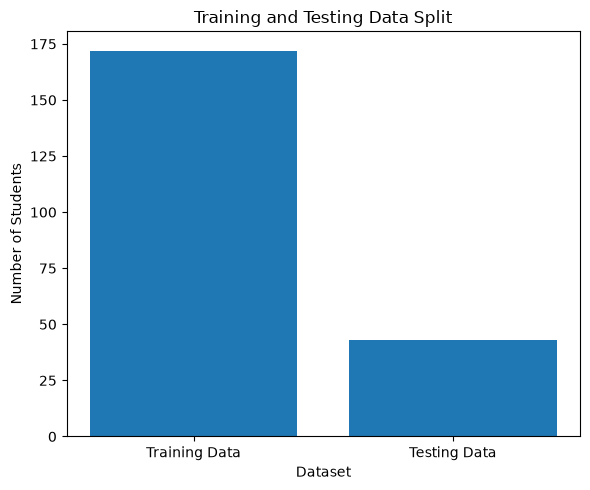

In [108]:

# Dataset sizes
data_sizes = [
    len(X_train),
    len(X_test)
]

labels = [
    'Training Data',
    'Testing Data'
]

plt.figure(figsize=(6, 5))

plt.bar(labels, data_sizes)

plt.title('Training and Testing Data Split')

plt.xlabel('Dataset')

plt.ylabel('Number of Students')

plt.tight_layout()

plt.show()

In [ ]:

numeric_columns = [
    'ssc_p',
    'hsc_p',
    'degree_p',
    'etest_p',
    'mba_p',
    'academic_average'
]

print("Numerical columns to be scaled:")
print(numeric_columns)



scaler = StandardScaler()

print("StandardScaler created successfully.")


scaler.fit(X_train[numeric_columns])

print("Scaler fitted using training data only.")



X_train[numeric_columns] = scaler.transform(
    X_train[numeric_columns]
)

print("Training numerical features scaled.")


X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

print("Testing numerical features scaled.")


print("Training data:")
display(X_train.head())

print("\nTesting data:")
display(X_test.head())



Numerical columns to be scaled:
['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'academic_average']
StandardScaler created successfully.
Scaler fitted using training data only.
Training numerical features scaled.
Testing numerical features scaled.
Training data:


,ssc_p,hsc_p,degree_p,etest_p,mba_p,academic_average,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
147,0.260729,0.694120,-0.166768,0.778647,0.000789,0.379859,1,0,0,1,0,0,0,0,0
161,-1.065759,-1.405431,-1.192126,-1.123471,0.074478,-1.471106,1,1,1,1,0,0,0,0,1
169,-0.664128,-2.212388,-0.678080,-1.359642,0.536711,-1.500787,1,1,1,0,1,0,1,0,1
131,0.712104,-0.857722,-0.576911,0.553721,-0.250425,-0.242626,0,1,1,0,1,1,0,1,0
27,-0.384091,0.055126,-0.030053,-0.345979,-0.767924,-0.156055,1,1,1,1,0,0,0,0,1



Testing data:


,ssc_p,hsc_p,degree_p,etest_p,mba_p,academic_average,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
63,-0.568326,0.328981,-0.303482,-0.308492,-0.464793,-0.197279,1,1,1,1,0,0,0,0,1
60,0.629198,0.328981,0.790234,-0.945780,-0.843288,0.668428,1,0,0,0,1,0,0,1,0
132,-0.015622,0.146411,-0.303482,0.133861,-1.471322,-0.032383,1,1,1,1,0,0,0,1,1
75,-0.752560,-0.401298,1.542163,0.103871,0.791273,-0.052995,0,0,1,1,0,0,0,0,1
16,-0.384091,-0.017901,-0.084739,-0.945780,0.044332,-0.205524,1,0,0,1,0,0,0,1,0


In [ ]:

print("Mean of scaled training features:")

print(
    X_train[numeric_columns].mean()
)

Mean of scaled training features:
ssc_p              -1.549148e-17
hsc_p              -9.630539e-16
degree_p            1.074076e-15
etest_p            -5.680211e-16
mba_p               1.879633e-15
academic_average    1.105059e-15
dtype: float64


In [ ]:

print("=" * 50)
print("FINAL DATA CHECK")
print("=" * 50)

print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

print("\nTraining target shape:")
print(y_train.shape)

print("\nTesting target shape:")
print(y_test.shape)

print("\nMissing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

print("\nMissing values in y_train:")
print(y_train.isnull().sum())

print("\nMissing values in y_test:")
print(y_test.isnull().sum())

FINAL DATA CHECK

Training data shape:
(172, 15)

Testing data shape:
(43, 15)

Training target shape:
(172,)

Testing target shape:
(43,)

Missing values in X_train:
0

Missing values in X_test:
0

Missing values in y_train:
0

Missing values in y_test:
0


In [ ]:

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

print("Logistic Regression model created.")


Logistic Regression model created.


In [ ]:

model.fit(
    X_train,
    y_train
)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:

y_pred = model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[1 1 1 0 1 0 1 1 0 1]


In [ ]:

comparison = pd.DataFrame({
    'Actual Status': y_test.values,
    'Predicted Status': y_pred
})

display(comparison.head(10))

,Actual Status,Predicted Status
0,0,1
1,1,1
2,1,1
3,0,0
4,1,1
5,0,0
6,1,1
7,1,1
8,0,0
9,1,1


In [ ]:

prediction_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

prediction_results['Actual'] = prediction_results['Actual'].map({
    1: 'Placed',
    0: 'Not Placed'
})

prediction_results['Predicted'] = prediction_results['Predicted'].map({
    1: 'Placed',
    0: 'Not Placed'
})

display(prediction_results.head(10))

,Actual,Predicted
0,Not Placed,Placed
1,Placed,Placed
2,Placed,Placed
3,Not Placed,Not Placed
4,Placed,Placed
5,Not Placed,Not Placed
6,Placed,Placed
7,Placed,Placed
8,Not Placed,Not Placed
9,Placed,Placed


In [ ]:

correct_predictions = (
    y_test == y_pred
).sum()

total_predictions = len(y_test)

print(
    "Correct Predictions:",
    correct_predictions
)

print(
    "Total Predictions:",
    total_predictions
)

Correct Predictions: 37
Total Predictions: 43


In [ ]:

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

display(
    feature_importance.head(10)
)

,Feature,Coefficient,Absolute_Coefficient
0,ssc_p,1.479742,1.479742
13,workex_Yes,1.456904,1.456904
5,academic_average,1.096837,1.096837
12,degree_t_Sci&Tech,-1.037327,1.037327
4,mba_p,-1.023483,1.023483
6,gender_M,0.904737,0.904737
2,degree_p,0.749073,0.749073
7,ssc_b_Others,0.529742,0.529742
1,hsc_p,0.462254,0.462254
10,hsc_s_Science,-0.355963,0.355963


In [ ]:

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 86.05 %


In [ ]:

precision = precision_score(
    y_test,
    y_pred
)

print(
    "Precision:",
    round(precision * 100, 2),
    "%"
)

Precision: 96.15 %


In [ ]:
recall = recall_score(
    y_test,
    y_pred
)

print(
    "Recall:",
    round(recall * 100, 2),
    "%"
)

Recall: 83.33 %


In [ ]:

f1 = f1_score(
    y_test,
    y_pred
)

print(
    "F1-Score:",
    round(f1 * 100, 2),
    "%"
)

F1-Score: 89.29 %


In [ ]:

metrics_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    
    'Score': [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_summary['Score (%)'] = (
    metrics_summary['Score'] * 100
).round(2)

display(
    metrics_summary[
        ['Metric', 'Score (%)']
    ]
)

,Metric,Score (%)
0,Accuracy,86.05
1,Precision,96.15
2,Recall,83.33
3,F1-Score,89.29


In [ ]:

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Not Placed',
            'Placed'
        ]
    )
)

              precision    recall  f1-score   support

  Not Placed       0.71      0.92      0.80        13
      Placed       0.96      0.83      0.89        30

    accuracy                           0.86        43
   macro avg       0.83      0.88      0.85        43
weighted avg       0.88      0.86      0.86        43



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[12  1]
 [ 5 25]]


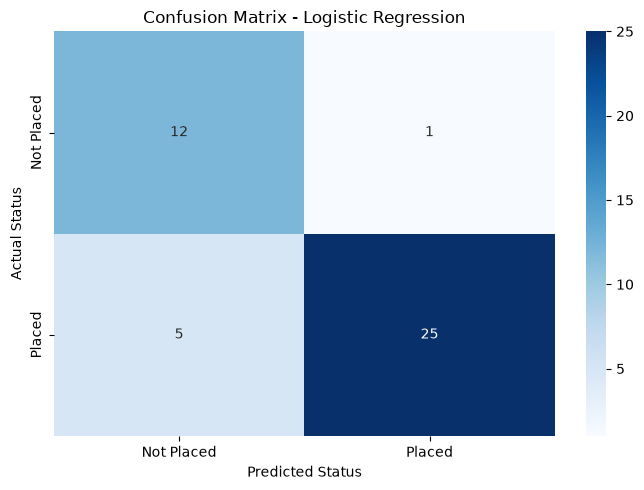

In [ ]:
# ==========================================
# STEP 8.10: CONFUSION MATRIX VISUALISATION
# ==========================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Not Placed',
        'Placed'
    ],
    yticklabels=[
        'Not Placed',
        'Placed'
    ]
)

plt.title('Confusion Matrix - Logistic Regression')

plt.xlabel('Predicted Status')

plt.ylabel('Actual Status')

plt.tight_layout()

# plt.savefig(
#     'confusion_matrix.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

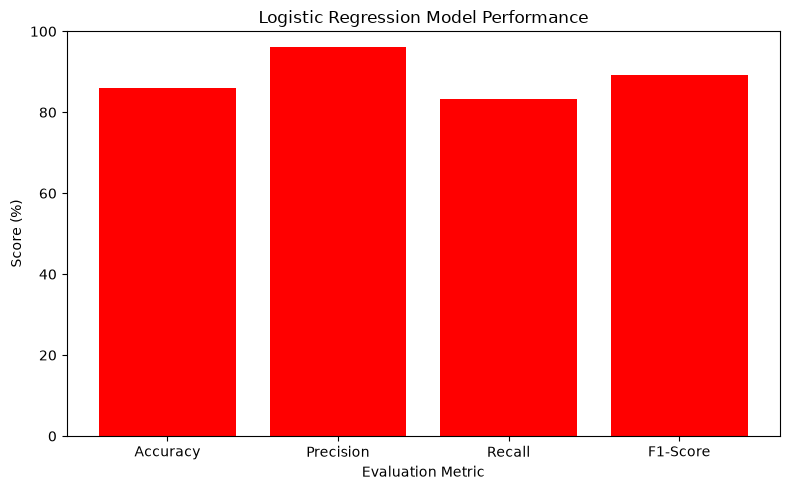

In [114]:

metric_names = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

metric_values = [
    accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100
]

plt.figure(figsize=(8, 5))

plt.bar(
    metric_names,
    metric_values,
    color = "red"
)

plt.title(
    'Logistic Regression Model Performance'
)

plt.xlabel(
    'Evaluation Metric'
)

plt.ylabel(
    'Score (%)'
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

# plt.savefig(
#     'model_performance.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [ ]:

metrics_summary.to_csv(
    'model_performance_metrics.csv',
    index=False
)

print(
    "Model performance metrics saved successfully."
)

Model performance metrics saved successfully.


In [ ]:

print("Top 10 Features Influencing Model Predictions:")

display(
    feature_importance[
        [
            'Feature',
            'Coefficient',
            'Absolute_Coefficient'
        ]
    ].head(10)
)

Top 10 Features Influencing Model Predictions:


,Feature,Coefficient,Absolute_Coefficient
0,ssc_p,1.479742,1.479742
13,workex_Yes,1.456904,1.456904
5,academic_average,1.096837,1.096837
12,degree_t_Sci&Tech,-1.037327,1.037327
4,mba_p,-1.023483,1.023483
6,gender_M,0.904737,0.904737
2,degree_p,0.749073,0.749073
7,ssc_b_Others,0.529742,0.529742
1,hsc_p,0.462254,0.462254
10,hsc_s_Science,-0.355963,0.355963


In [ ]:

recommendations = pd.DataFrame({
    'Area': [
        'Academic Performance',
        'Employability Skills',
        'Work Experience',
        'Interview Preparation',
        'Career Guidance'
    ],
    
    'Recommendation': [
        'Students should maintain consistent academic performance across school and degree education.',
        
        'Students should regularly practice aptitude, reasoning, communication, and technical assessment skills.',
        
        'Students should consider internships, projects, or relevant practical experience to improve industry readiness.',
        
        'Students should participate in mock interviews and improve communication and presentation skills.',
        
        'Colleges should provide targeted career guidance and additional support to students who may need placement preparation.'
    ]
})

display(recommendations)

,Area,Recommendation
0,Academic Performance,Students should maintain consistent academic p...
1,Employability Skills,"Students should regularly practice aptitude, r..."
2,Work Experience,"Students should consider internships, projects..."
3,Interview Preparation,Students should participate in mock interviews...
4,Career Guidance,Colleges should provide targeted career guidan...


In [ ]:

for index, row in recommendations.iterrows():
    
    print(
        f"{index + 1}. {row['Area']}"
    )
    
    print(
        f"   Recommendation: {row['Recommendation']}"
    )
    
    print()

1. Academic Performance
   Recommendation: Students should maintain consistent academic performance across school and degree education.

2. Employability Skills
   Recommendation: Students should regularly practice aptitude, reasoning, communication, and technical assessment skills.

3. Work Experience
   Recommendation: Students should consider internships, projects, or relevant practical experience to improve industry readiness.

4. Interview Preparation
   Recommendation: Students should participate in mock interviews and improve communication and presentation skills.

5. Career Guidance
   Recommendation: Colleges should provide targeted career guidance and additional support to students who may need placement preparation.



In [ ]:

top_feature_names = feature_importance.head(10)['Feature'].tolist()

print("Top model features:")
for feature in top_feature_names:
    print("-", feature)

Top model features:
- ssc_p
- workex_Yes
- academic_average
- degree_t_Sci&Tech
- mba_p
- gender_M
- degree_p
- ssc_b_Others
- hsc_p
- hsc_s_Science


In [ ]:

top_features = feature_importance.head(10)['Feature'].tolist()

print("PERSONALISED PLACEMENT RECOMMENDATIONS")
print("=" * 50)

# Academic recommendation
if any(
    feature in top_features
    for feature in [
        'ssc_p',
        'hsc_p',
        'degree_p',
        'academic_average'
    ]
):
    print(
        "1. Academic Improvement:"
    )
    print(
        "   Focus on maintaining strong academic performance "
        "throughout the student's education."
    )
    print()

# Employability test recommendation
if 'etest_p' in top_features:
    print(
        "2. Employability Test Preparation:"
    )
    print(
        "   Students should practice aptitude, reasoning, "
        "and other employability assessment skills."
    )
    print()

# Work experience recommendation
if 'workex_Yes' in top_features:
    print(
        "3. Practical Experience:"
    )
    print(
        "   Students should consider internships, live projects, "
        "or relevant practical experience."
    )
    print()

# MBA recommendation
if 'mba_p' in top_features:
    print(
        "4. MBA Performance:"
    )
    print(
        "   Students should focus on improving their postgraduate "
        "academic performance and relevant skills."
    )
    print()

PERSONALISED PLACEMENT RECOMMENDATIONS
1. Academic Improvement:
   Focus on maintaining strong academic performance throughout the student's education.

3. Practical Experience:
   Students should consider internships, live projects, or relevant practical experience.

4. MBA Performance:
   Students should focus on improving their postgraduate academic performance and relevant skills.



In [ ]:

categorical_columns = [
    'gender',
    'ssc_b',
    'hsc_b',
    'hsc_s',
    'degree_t',
    'workex',
    'specialisation'
]

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 gender
['M' 'F']

 ssc_b
['Others' 'Central']

 hsc_b
['Others' 'Central']

 hsc_s
['Commerce' 'Science' 'Arts']

 degree_t
['Sci&Tech' 'Comm&Mgmt' 'Others']

 workex
['No' 'Yes']

 specialisation
['Mkt&HR' 'Mkt&Fin']


In [ ]:

new_student = pd.DataFrame({
    'gender': ['M'],
    'ssc_p': [75],
    'ssc_b': ['Central'],
    'hsc_p': [72],
    'hsc_b': ['Central'],
    'hsc_s': ['Commerce'],
    'degree_p': [70],
    'degree_t': ['Comm&Mgmt'],
    'workex': ['Yes'],
    'etest_p': [80],
    'specialisation': ['Mkt&Fin'],
    'mba_p': [75]
})

display(new_student)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p
0,M,75,Central,72,Central,Commerce,70,Comm&Mgmt,Yes,80,Mkt&Fin,75


In [ ]:

new_student['academic_average'] = new_student[
    ['ssc_p', 'hsc_p', 'degree_p']
].mean(axis=1)

display(new_student)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,academic_average
0,M,75,Central,72,Central,Commerce,70,Comm&Mgmt,Yes,80,Mkt&Fin,75,72.333333


In [ ]:

new_student_encoded = pd.get_dummies(
    new_student,
    columns=categorical_columns,
    drop_first=True
)

display(new_student_encoded)

,ssc_p,hsc_p,degree_p,etest_p,mba_p,academic_average
0,75,72,70,80,75,72.333333


In [ ]:

new_student_encoded = new_student_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

print(
    "New student columns matched with training data."
)

display(new_student_encoded)

New student columns matched with training data.


,ssc_p,hsc_p,degree_p,etest_p,mba_p,academic_average,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,75,72,70,80,75,72.333333,0,0,0,0,0,0,0,0,0


In [ ]:
new_student_encoded = new_student_encoded.astype(float)

print(
    "Data types converted successfully."
)

Data types converted successfully.


In [ ]:

new_student_encoded[numeric_columns] = scaler.transform(
    new_student_encoded[numeric_columns]
)

print(
    "New student numerical features scaled."
)

display(new_student_encoded)

New student numerical features scaled.


,ssc_p,hsc_p,degree_p,etest_p,mba_p,academic_average,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,0.721316,0.511551,0.516805,0.553721,2.131078,0.709652,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

prediction = model.predict(
    new_student_encoded
)

print(
    "Prediction value:",
    prediction[0]
)

Prediction value: 1


In [ ]:

if prediction[0] == 1:
    print("🎯 Placement Prediction: PLACED")
else:
    print("🎯 Placement Prediction: NOT PLACED")

🎯 Placement Prediction: PLACED


In [ ]:

probabilities = model.predict_proba(
    new_student_encoded
)

placement_probability = probabilities[0][1]

print(
    "Placement Probability:",
    round(
        placement_probability * 100,
        2
    ),
    "%"
)

Placement Probability: 63.43 %


In [ ]:

if prediction[0] == 1:
    
    print("=" * 50)
    print("🎯 PLACEMENT PREDICTION")
    print("=" * 50)
    
    print("Result: PLACED")
    
    print(
        "Placement Probability:",
        round(
            placement_probability * 100,
            2
        ),
        "%"
    )

else:
    
    print("=" * 50)
    print("🎯 PLACEMENT PREDICTION")
    print("=" * 50)
    
    print("Result: NOT PLACED")
    
    print(
        "Placement Probability:",
        round(
            placement_probability * 100,
            2
        ),
        "%"
    )

🎯 PLACEMENT PREDICTION
Result: PLACED
Placement Probability: 63.43 %


In [ ]:

print("\n📌 STUDENT IMPROVEMENT RECOMMENDATIONS")
print("=" * 50)

recommendation_found = False

# Academic performance
if new_student['academic_average'].iloc[0] < 60:
    print(
        "• Focus on improving overall academic performance."
    )
    recommendation_found = True

# Employability test
if new_student['etest_p'].iloc[0] < 60:
    print(
        "• Practice aptitude and employability tests regularly."
    )
    recommendation_found = True

# MBA performance
if new_student['mba_p'].iloc[0] < 60:
    print(
        "• Focus on improving MBA academic performance."
    )
    recommendation_found = True

# Work experience
if new_student['workex'].iloc[0] == 'No':
    print(
        "• Consider internships, live projects, or practical training."
    )
    recommendation_found = True

# If no specific weakness found
if recommendation_found == False:
    print(
        "• Continue maintaining strong academic and employability performance."
    )
    
    print(
        "• Continue developing communication and interview skills."
    )


📌 STUDENT IMPROVEMENT RECOMMENDATIONS
• Continue maintaining strong academic and employability performance.
• Continue developing communication and interview skills.


In [ ]:

def predict_student_placement(
    gender,
    ssc_p,
    ssc_b,
    hsc_p,
    hsc_b,
    hsc_s,
    degree_p,
    degree_t,
    workex,
    etest_p,
    specialisation,
    mba_p
):
    
    # Create student DataFrame
    student = pd.DataFrame({
        'gender': [gender],
        'ssc_p': [ssc_p],
        'ssc_b': [ssc_b],
        'hsc_p': [hsc_p],
        'hsc_b': [hsc_b],
        'hsc_s': [hsc_s],
        'degree_p': [degree_p],
        'degree_t': [degree_t],
        'workex': [workex],
        'etest_p': [etest_p],
        'specialisation': [specialisation],
        'mba_p': [mba_p]
    })
    
    # Create academic average
    student['academic_average'] = student[
        ['ssc_p', 'hsc_p', 'degree_p']
    ].mean(axis=1)
    
    # Encode categorical features
    student_encoded = pd.get_dummies(
        student,
        columns=categorical_columns,
        drop_first=True
    )
    
    # Match training columns
    student_encoded = student_encoded.reindex(
        columns=X_train.columns,
        fill_value=0
    )
    
    # Convert data type
    student_encoded = student_encoded.astype(float)
    
    # Scale numerical columns
    student_encoded[numeric_columns] = scaler.transform(
        student_encoded[numeric_columns]
    )
    
    # Make prediction
    prediction = model.predict(
        student_encoded
    )[0]
    
    # Get probability
    probability = model.predict_proba(
        student_encoded
    )[0][1]
    
    # Display result
    if prediction == 1:
        result = "PLACED"
    else:
        result = "NOT PLACED"
    
    print("=" * 50)
    print("STUDENT PLACEMENT PREDICTION")
    print("=" * 50)
    
    print("Prediction:", result)
    
    print(
        "Placement Probability:",
        round(
            probability * 100,
            2
        ),
        "%"
    )
    
    print("=" * 50)
    
    return prediction, probability

In [ ]:
prediction, probability = predict_student_placement(
    gender='M',
    ssc_p=25,
    ssc_b='Central',
    hsc_p=72,
    hsc_b='Central',
    hsc_s='Commerce',
    degree_p=70,
    degree_t='Comm&Mgmt',
    workex='Yes',
    etest_p=80,
    specialisation='Mkt&Fin',
    mba_p=75
)

STUDENT PLACEMENT PREDICTION
Prediction: NOT PLACED
Placement Probability: 0.02 %


In [ ]:
import joblib

joblib.dump(
    model,
    'logistic_regression_model.pkl'
)

joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']